In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
file_path = "breast_cancer/data.csv"
with open(file_path) as file:
    csvFile = pd.read_csv(file)
    df = pd.DataFrame(csvFile)

area = df["area_mean"]
concavity = df["concavity_mean"]
diagnosis = df["diagnosis"] 

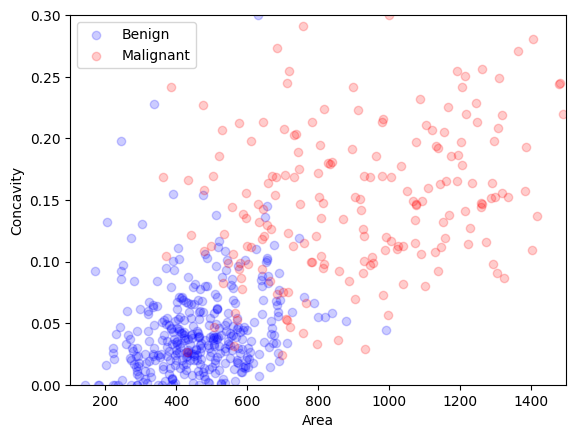

In [5]:
indices_m = [i for i in range(len(diagnosis)) if diagnosis[i]=="M" ]
diagnosis_m = diagnosis[indices_m]
area_m = area[indices_m]
concavity_m = concavity[indices_m]

indices_b = [i for i in range(len(diagnosis)) if diagnosis[i]=="B" ]
diagnosis_b = diagnosis[indices_b]
area_b = area[indices_b]
concavity_b = concavity[indices_b]

plt.scatter(area_b, concavity_b,  color="b", alpha=0.2, label="Benign")
plt.scatter(area_m, concavity_m,  color="r", alpha=0.2, label="Malignant")
plt.xlim([100, 1500])
plt.ylim([0, 0.3])
plt.xlabel("Area")
plt.ylabel("Concavity")
plt.legend()

In [3]:
import numpy as np
class Predictor:
    """
    I made this to translate between non-normalized queries, using a normalized model.
    """
    def __init__(self, X: list, y: list, classifier):
        X = np.array(X)
        X_normalized = self.normalize_training_data(X)
        
        self.classifier = classifier
        self.classifier.fit(X_normalized, y)
    
    def normalize_training_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)
        min_max_values = np.zeros((X.shape[1], 2))

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - np.min(X[:, i])) / (np.max(X[:, i]) - np.min(X[:, i]))
            min_max_values[i, 0] = np.min(X[:, i])
            min_max_values[i, 1] = np.max(X[:, i])
        
        self.min_max_training_values = min_max_values

        return new_X
    
    def normalize_test_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - self.min_max_training_values[i, 0]) / (self.min_max_training_values[i, 1] - self.min_max_training_values[i, 0])
        
        return new_X

    def predict(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict(X_normalized)
    
    def predict_proba(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict_proba(X_normalized)
    
    def score(self, X, y):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.score(X_normalized, y)

In [4]:

from sklearn.model_selection import train_test_split

MALIGNANT = 1
BENIGN = -1

X = np.array([[a, c] for a, c in zip(area, concavity)])
y = np.array([MALIGNANT if d=="M" else BENIGN for d in diagnosis])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(fit_intercept=True)
clf = LogisticRegression(fit_intercept=True, solver="newton-cholesky", penalty=None, max_iter=100000, tol=1e-9)
predictor = Predictor(X_train, y_train, clf)

/home/wyrgly/projects/coursework/winter2026/ecen471/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
from sklearn.metrics import classification_report

def missclassification_rate(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return 1 - report['accuracy'] # Page 63 of textbook states, "1 minus the misclassification rate as the accuracy"

In [7]:
import warnings
import numpy as np

warnings.filterwarnings('ignore')
count = 0

@np.vectorize
def find_intercept(theta_1, theta_2, min=-10, max=-6, M=40):
    global count
    count += 1
    # print(count)
    intercepts = np.linspace(min, max, M)
    J = np.zeros_like(intercepts)
    for i, intercept in enumerate(intercepts):
        predictor.classifier.intercept_ = intercept
        predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
        J[i] = missclassification_rate(y_train, predictor.predict(X_train))
    
    optimal_intercept = intercepts[np.argmin(J)]
    return optimal_intercept

theta1 = np.linspace(8, 60, 50)
theta2 = np.linspace(2, 35, 50)
THETA1, THETA2 = np.meshgrid(theta1, theta2)
intercepts = find_intercept(THETA1, THETA2)

In [8]:
@np.vectorize
def calculate_cost_function(theta_1, theta_2, intercept):
    predictor.classifier.intercept_ = intercept
    predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
    J = missclassification_rate(y_train, predictor.predict(X_train))
    return J

J = calculate_cost_function(THETA1, THETA2, intercepts)

theta1_opt = THETA1.ravel()[np.argmin(J.ravel())]
theta2_opt = THETA2.ravel()[np.argmin(J.ravel())]
intercept_opt = intercepts.ravel()[np.argmin(J.ravel())]


predictor.classifier.coef_ = np.array([[theta1_opt, theta2_opt]]) 
predictor.classifier.intercept_ = intercept_opt
print(missclassification_rate(y_train, predictor.predict(X_train)))
print(missclassification_rate(y_test, predictor.predict(X_test)))

0.06813186813186811
0.11403508771929827


In [9]:
import pickle

data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "coefs": predictor.classifier.coef_,
    "intercept": predictor.classifier.intercept_,
    "THETA1": THETA1,
    "THETA2": THETA2,
    "COST_FUNCTION": J,
}

pickle.dump(data, open('processed_data.pkl', 'wb'))